In [3]:
%pip install numpy==1.26.4
%pip install pmdarima


     ---------------------------------------- 15.8/15.8 MB 2.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\shaun\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\~umpy.libs\\libscipy_openblas64_-13e2df515630b4a41f92893938845698.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.2.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [107]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
#!pip install pmdarima
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pmd
from pmdarima import auto_arima


In [41]:

repo_root = Path('C:/Users/shaun/Documents/GitHub/2025H5_GroupE')

DOCS  = repo_root / "data" / "clean_datasets"
CLEAN_FINAL_CSV = DOCS / "Final_master_daily_with_env.csv"

# Load data
df = pd.read_csv(CLEAN_FINAL_CSV, parse_dates=['DATE'], index_col='DATE')
demanddaily = df.sort_index()
demanddaily = demanddaily.iloc[:-1]


In [152]:
## Model setup

# Select target
target = 'demand_mw_mean'

# Exclude leakage columns
exclude_cols = ['demand_mw_sum', 'demand_mw_mean', 'demand_mw_max', 'forecast_mw_sum', 'forecast_mw_mean', 'forecast_mw_max', 'fcst_error_mean', 'fcst_abs_error_sum', 'fcst_ape_mean'
				, 'F_P7_sin1', 'F_P7_cos1', 'F_P7_sin2', 'F_P7_cos2', 'F_P7_sin3', 'F_P7_cos3'
				, 'demand_mw_sum_lag1', 'demand_mw_sum_lag7', 'demand_mw_sum_lag14', 'demand_mw_sum_lag28', 'demand_mw_sum_roll7_mean', 'demand_mw_sum_roll7_std'
				, 'demand_mw_sum_roll14_mean', 'demand_mw_sum_roll14_std', 'temp_c_mean_lag1', 'temp_c_mean_lag7', 'forecast_mw_sum_lag1', 'forecast_mw_sum_lag7'
				, 'month', 'day', 'dow'
				#, 'F_P365_sin1', 'F_P365_cos1', 'F_P365_sin2', 'F_P365_cos2', 'F_P365_sin3', 'F_P365_cos3'
				]
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Handle missing values: drop rows with NaN
demanddaily = demanddaily.dropna()

# Extract X (features) and y (target)
X = demanddaily[feature_cols]
y = demanddaily[target].astype('float64') 

print(feature_cols)

['year', 'is_weekend', 'is_holiday', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'F_P365_sin1', 'F_P365_cos1', 'F_P365_sin2', 'F_P365_cos2', 'F_P365_sin3', 'F_P365_cos3', 'cloud_cover', 'humidity', 'irradiance', 'precipitation', 'rn_temp_c', 'wind_speed', 'rn_temp_c_max', 'wind_speed_max', 'irradiance_max', 'precipitation_max', 'cloud_cover_max', 'humidity_max']


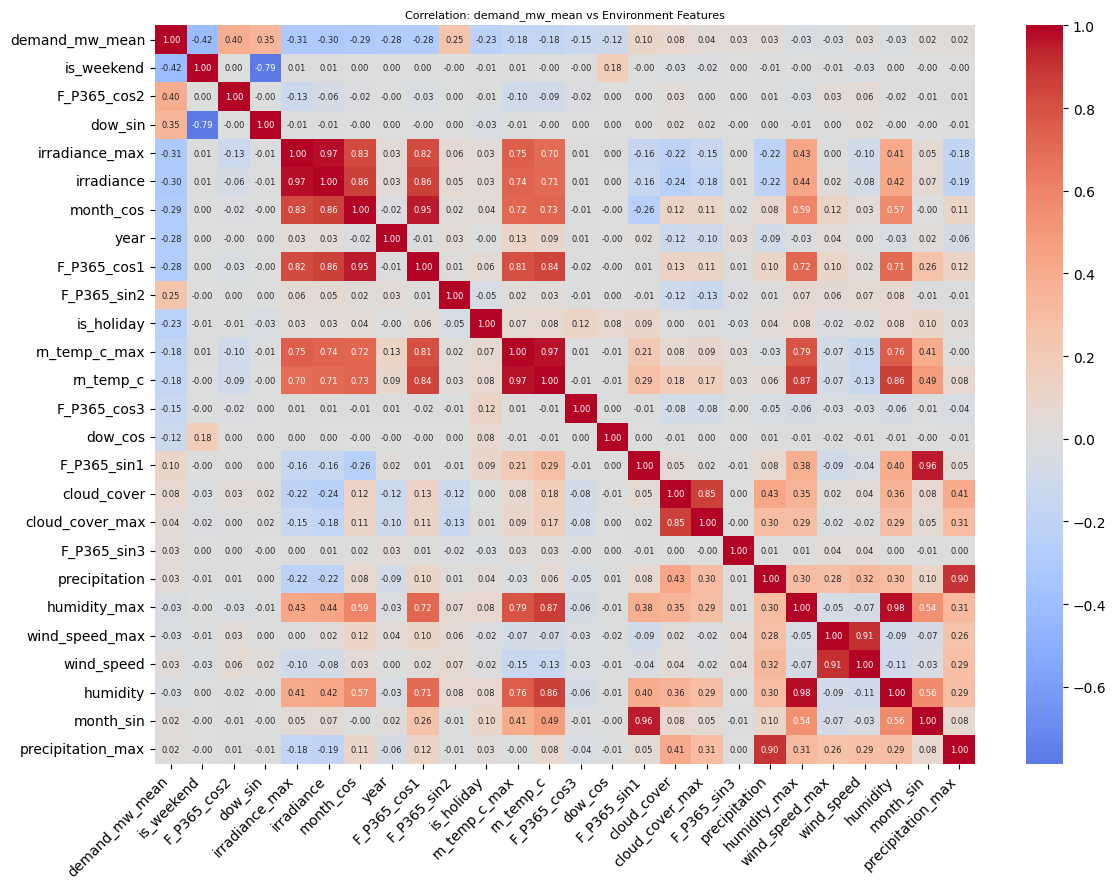

In [154]:

# Cast to numeric first (older pandas has no numeric_only in corr)
num = demanddaily[[target] + feature_cols].apply(pd.to_numeric, errors="coerce")
num = num.dropna(axis=1, how="all")  # in case any column becomes all-NaN

corr = num.corr()

# Order by |corr| with target for a cleaner view
order = corr[target].abs().dropna().sort_values(ascending=False).index
corr = corr.loc[order, order]

# Same format & size as original, slightly tidied labels
plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", annot_kws={"size": 6})
plt.title("Correlation: demand_mw_mean vs Environment Features", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Clean Features (Remove High Correlations):
Keep:
F_sin1 / F_cos1 # Models yearly trend
rn_temp_c
humidity
cloud_cover
irradiance
precipitation
wind_speed



Drop:
F_sin2 / F_cos2, F_sin3 / F_cos3 
rn_temp_c_max # Correlated with m_temp_c
humidity_max # Correlated with humidity 
month_sin / month_cos # Correlated with F_sin1
cloud_cover_max
irradiance_max
precipitation_max
wind_speed_max
year  # Captured by differencing





In [160]:
exclude_cols2 = ['rn_temp_c_max', 'humidity_max', 'cloud_cover_max', 'irradiance_max', 'precipitation_max', 'wind_speed_max' 
				, 'F_P365_sin2', 'F_P365_cos2', 'F_P365_sin3', 'F_P365_cos3'
				, 'year', 'month_sin', 'month_cos'
				, 'dow_sin', 'dow_cos'
				, 'humidity'
				, 'F_P365_sin1', 'F_P365_cos1'
				]
feature_cols2 = [col for col in feature_cols if col not in exclude_cols2]

# Extract X (features) and y (target)
X2 = X[feature_cols2]

print(feature_cols2)

['is_weekend', 'is_holiday', 'cloud_cover', 'irradiance', 'precipitation', 'rn_temp_c', 'wind_speed']


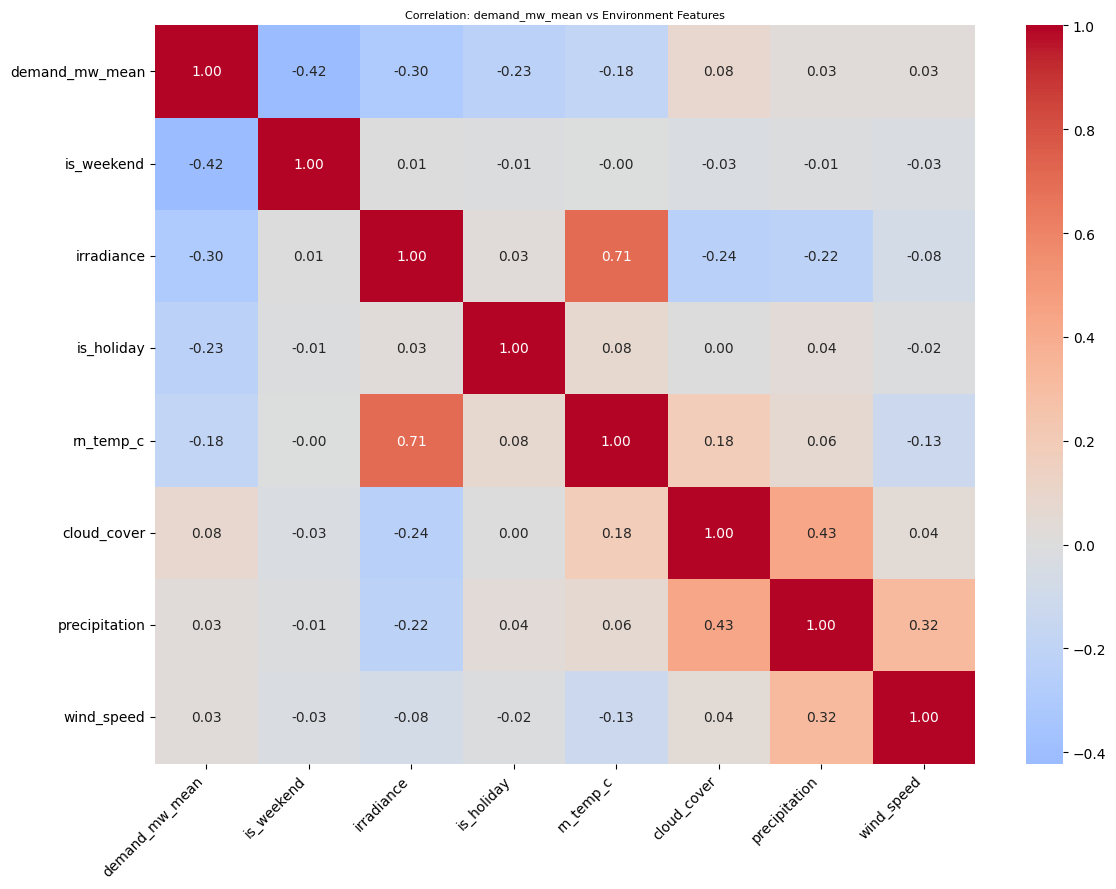

In [162]:
## Recheck correlation

# Cast to numeric first (older pandas has no numeric_only in corr)
num = demanddaily[[target] + feature_cols2].apply(pd.to_numeric, errors="coerce")
num = num.dropna(axis=1, how="all")  # in case any column becomes all-NaN

corr = num.corr()

# Order by |corr| with target for a cleaner view
order = corr[target].abs().dropna().sort_values(ascending=False).index
corr = corr.loc[order, order]

# Same format & size as original, slightly tidied labels
plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", annot_kws={"size": 10})
plt.title("Correlation: demand_mw_mean vs Environment Features", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [167]:
## Split train / validation / test

# split sizes
train_end = 8*365        # ~8 years of daily data
val_end   = train_end + 2*365
test_end  = val_end + 365

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:test_end]

X_train = X[:train_end]
X_val   = X[train_end:val_end]
X_test  = X[val_end:test_end]

X2_train = X2[:train_end]
X2_val   = X2[train_end:val_end]
X2_test  = X2[val_end:test_end]


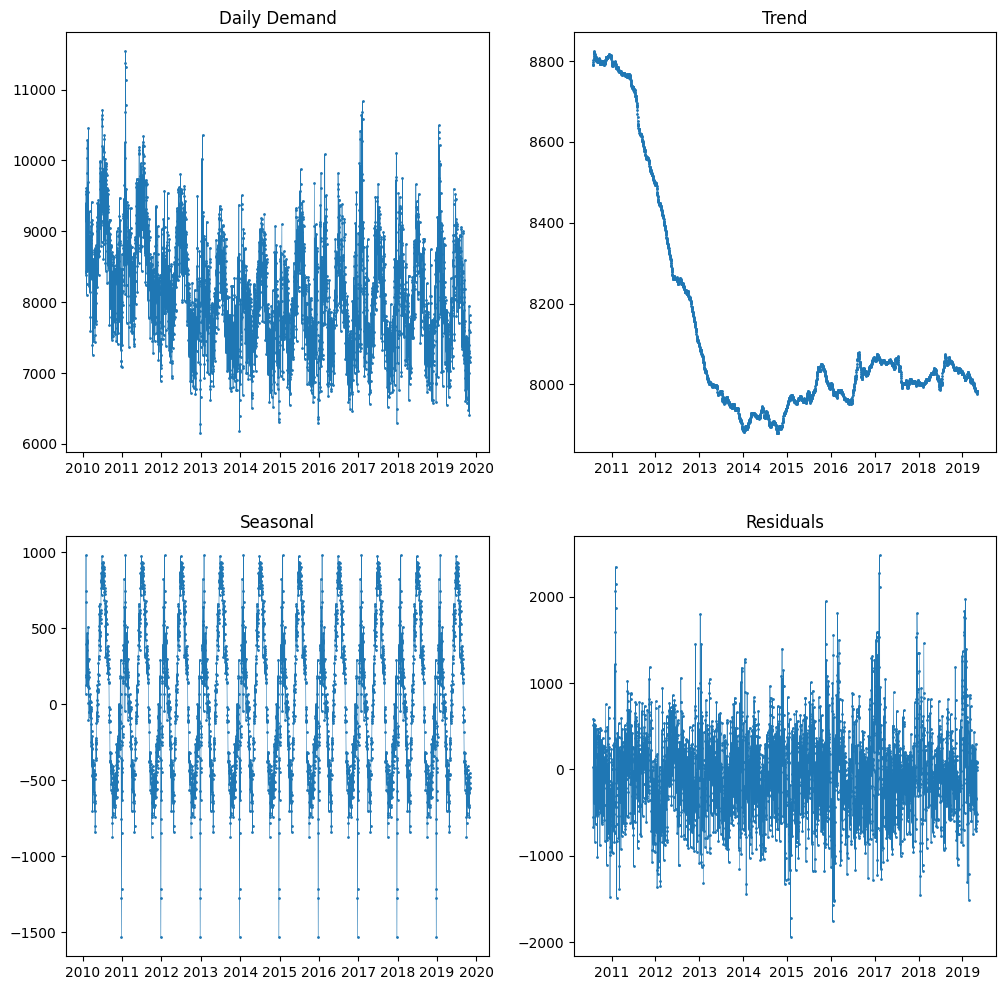

In [140]:
## Check variance stability

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

decomposition=seasonal_decompose(demanddaily[target],model='additive',period=365)
line_kwargs = dict(linewidth=0.4, markersize=1, marker='o')

axes[0,0].plot(demanddaily[target], **line_kwargs)
axes[0,0].set_title('Daily Demand')

axes[0,1].plot(decomposition.trend, **line_kwargs)
axes[0,1].set_title('Trend')

axes[1,0].plot(decomposition.seasonal, **line_kwargs)
axes[1,0].set_title('Seasonal')

axes[1,1].plot(decomposition.resid, **line_kwargs)
axes[1,1].set_title('Residuals')

plt.show()


Residuals show no pattern.

But trend is strongly down.

So assume variance is stable.

But clear evidence of a long term trend.


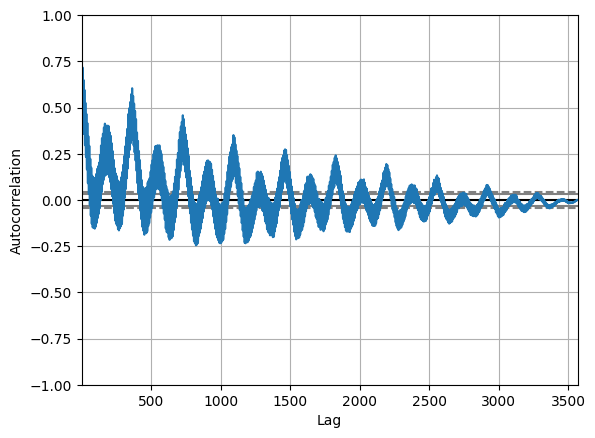

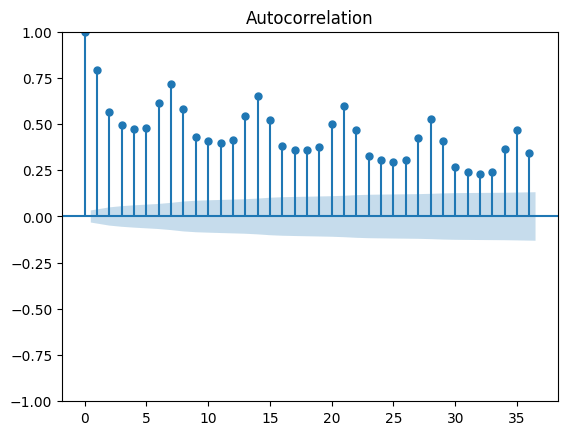

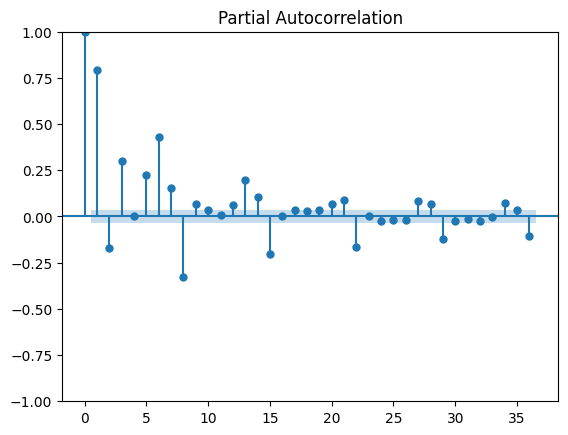

In [141]:
## Look at seasonality

autocorrelation_plot(demanddaily[target])

#ACF plots

plot_acf(demanddaily[target])
plt.show()

plot_pacf(demanddaily[target])
plt.show()

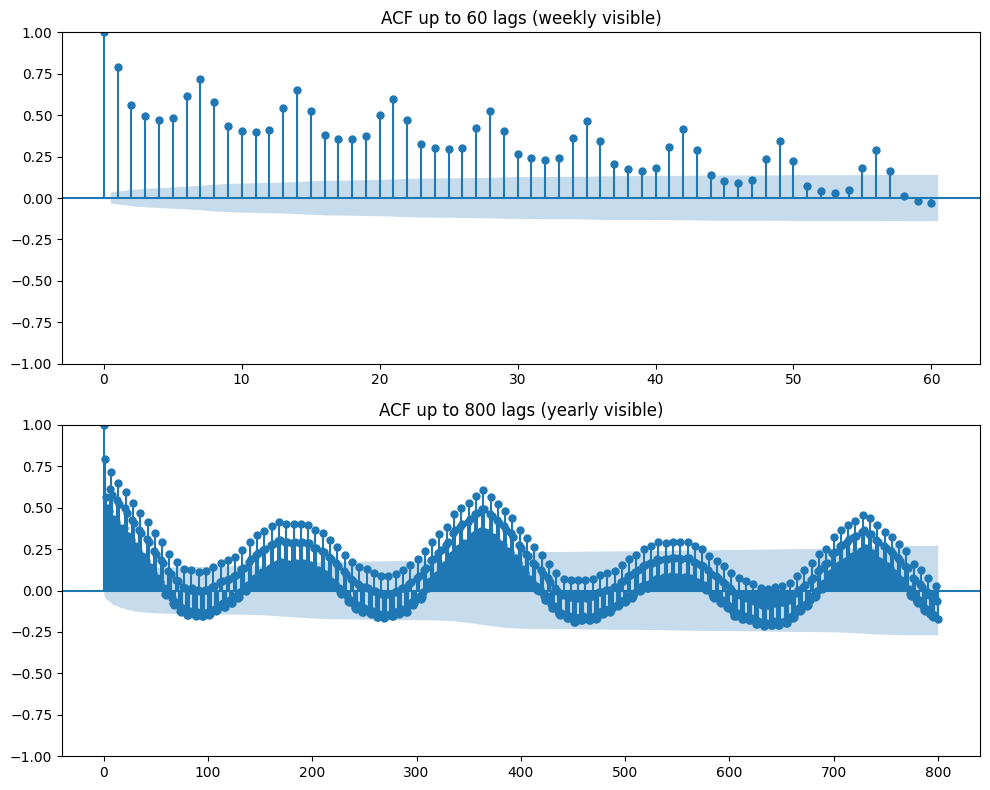

In [128]:
fig, axes = plt.subplots(2, 1, figsize=(10,8))

# Look for weekly pattern
plot_acf(demanddaily[target], lags=60, ax=axes[0])
axes[0].set_title("ACF up to 60 lags (weekly visible)")

# Look for yearly pattern
plot_acf(demanddaily[target], lags=800, ax=axes[1])
axes[1].set_title("ACF up to 800 lags (yearly visible)")

plt.tight_layout()
plt.show()


Two seasonal trends:

Weekly seasonality

Yearly seasonality

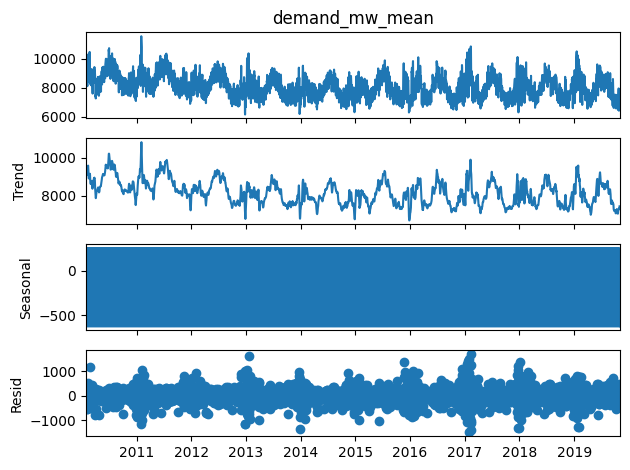

In [129]:
decomposition=seasonal_decompose(demanddaily[target],model='additive',period=7)
decomposition.plot()
plt.show()

In [142]:
## Test for stationarity

y = y_train

adf_y = adfuller(y, autolag='AIC')
print("11. ADF Statistic(y) : ", adf_y[0])
print("12. P-Value : ", adf_y[1])
print("\n")

kpss_y = kpss(y, regression = 'c', nlags='auto')
print("13. KPSS Statistic(y) : ", kpss_y[0])
print("14. P-Value : ", kpss_y[1])
print("\n")

demand_diff = y.diff()

demand_diff = demand_diff.dropna()

adf_dy = adfuller(demand_diff, autolag='AIC')
print("21. ADF Statistic(dy) : ", adf_dy[0])
print("22. P-Value : ", adf_dy[1])
print("\n")

kpss_dy = kpss(demand_diff, regression = 'c', nlags='auto')
print("23. KPSS Statistic(dy) : ", kpss_dy[0])
print("24. P-Value : ", kpss_dy[1])


11. ADF Statistic(y) :  -4.797934835861826
12. P-Value :  5.4882825755950835e-05


13. KPSS Statistic(y) :  2.5918982593103603
14. P-Value :  0.01


21. ADF Statistic(dy) :  -12.515687557932054
22. P-Value :  2.614709815227465e-23


23. KPSS Statistic(dy) :  0.024970384911925853
24. P-Value :  0.1


C:\Users\shaun\AppData\Local\Temp\ipykernel_1032\2437191959.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_y = kpss(y, regression = 'c', nlags='auto')
C:\Users\shaun\AppData\Local\Temp\ipykernel_1032\2437191959.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_dy = kpss(demand_diff, regression = 'c', nlags='auto')


Conclude d = 1.

I.e there is a linear trend in daily demand.


In [131]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from pmdarima.warnings import ModelFitWarning
warnings.simplefilter(action='ignore', category=ModelFitWarning)

In [143]:
fourier_year1 = X_train[['F_P365_sin1', 'F_P365_cos1']]
fourier_year2 = X_train[['F_P365_sin1', 'F_P365_cos1', 'F_P365_sin2', 'F_P365_cos2']]
fourier_year3 = X_train[['F_P365_sin1', 'F_P365_cos1', 'F_P365_sin2', 'F_P365_cos2', 'F_P365_sin3', 'F_P365_cos3']]

In [173]:
## Test auto_ARIMA fit
## Include Fourier breeakdown to account for long term trend
## Only order one to as limited impact over 28 day forecast horizon

model=pmd.auto_arima(y_train
					 , exogenous = fourier_year1
					 ,start_p=1, start_q=1
					 ##, d=1, D=0
					 ,test='kpss', m=7
					 ,seasonal=True
					 ,trace=True
					 , with_intercept = True)

## 9/18 AIC=inf
## Use mean instead of sum as outcome
## 9/22 AIC=inf

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=6.00 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=44657.772, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=43392.418, Time=1.15 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=43936.319, Time=1.45 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=44655.774, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=44652.939, Time=0.12 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=43045.282, Time=2.30 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=8.36 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=4.12 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=43043.389, Time=1.99 sec
 ARIMA(0,1,0)(1,0,0)[7] intercept   : AIC=43390.937, Time=0.66 sec
 ARIMA(0,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=5.54 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=3.24 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=43045.189, Time=2.45 sec
 ARIMA(1,1,1)(2,0,0)[7] intercept   : AIC=inf, Ti

In [ ]:
## Test auto_ARIMA fit
## Include Fourier breeakdown to account for long term trend
## Only order one to as limited impact over 28 day forecast horizon

model=pmd.auto_arima(y_train
					 , exogenous = fourier_year1
					 ,start_p=1, start_q=1
					 , d=1, D=0
					 ,test='adf', m=7
					 ,seasonal=True
					 ,trace=True
					 , with_intercept = False)

## 6 / 15 have AIC=inf
## Use mean instead of sum as outcome
## 6/15 AIC=inf

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[7]             : AIC=inf, Time=3.12 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=44655.774, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[7]             : AIC=43390.427, Time=0.64 sec
 ARIMA(0,1,1)(0,0,1)[7]             : AIC=43934.322, Time=0.84 sec
 ARIMA(1,1,0)(0,0,0)[7]             : AIC=44650.939, Time=0.08 sec
 ARIMA(1,1,0)(2,0,0)[7]             : AIC=43043.304, Time=1.01 sec
 ARIMA(1,1,0)(2,0,1)[7]             : AIC=inf, Time=3.06 sec
 ARIMA(1,1,0)(1,0,1)[7]             : AIC=inf, Time=1.65 sec
 ARIMA(0,1,0)(2,0,0)[7]             : AIC=43041.412, Time=0.26 sec
 ARIMA(0,1,0)(1,0,0)[7]             : AIC=43388.947, Time=0.11 sec
 ARIMA(0,1,0)(2,0,1)[7]             : AIC=inf, Time=4.43 sec
 ARIMA(0,1,0)(1,0,1)[7]             : AIC=inf, Time=1.38 sec
 ARIMA(0,1,1)(2,0,0)[7]             : AIC=43043.212, Time=0.98 sec
 ARIMA(1,1,1)(2,0,0)[7]             : AIC=inf, Time=2.45 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=43043.389, Ti

In [178]:
## Test auto_ARIMA fit
## Include Fourier breeakdown to account for long term trend
## Only order one to as limited impact over 28 day forecast horizon

model=pmd.auto_arima(y_train
					 , exogenous = fourier_year1
					 ,start_p=1, start_q=1
					 , d=1, D=0
					 ,test='adf', m=7
					 ,seasonal=True
					 ,trace=True
					 , with_intercept = False)

## 6 / 15 have AIC=inf
## Use mean instead of sum as outcome
## 6/15 AIC=inf

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[7]             : AIC=inf, Time=2.14 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=44655.774, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7]             : AIC=43390.427, Time=0.46 sec
 ARIMA(0,1,1)(0,0,1)[7]             : AIC=43934.322, Time=0.56 sec
 ARIMA(1,1,0)(0,0,0)[7]             : AIC=44650.939, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[7]             : AIC=43043.304, Time=0.90 sec
 ARIMA(1,1,0)(2,0,1)[7]             : AIC=inf, Time=3.01 sec
 ARIMA(1,1,0)(1,0,1)[7]             : AIC=inf, Time=1.49 sec
 ARIMA(0,1,0)(2,0,0)[7]             : AIC=43041.412, Time=0.28 sec
 ARIMA(0,1,0)(1,0,0)[7]             : AIC=43388.947, Time=0.11 sec
 ARIMA(0,1,0)(2,0,1)[7]             : AIC=inf, Time=4.42 sec
 ARIMA(0,1,0)(1,0,1)[7]             : AIC=inf, Time=1.37 sec
 ARIMA(0,1,1)(2,0,0)[7]             : AIC=43043.212, Time=1.09 sec
 ARIMA(1,1,1)(2,0,0)[7]             : AIC=inf, Time=2.46 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=43043.389, Ti

In [179]:
## Fit with full exogenous feature set.

model=pmd.auto_arima(y_train
					 , exogenous = X_tr
					 ,start_p=1, start_q=1
					 , d=1, D=0
					 ,test='adf', m=7
					 ,seasonal=True
					 ,trace=True
					 , with_intercept = False)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[7]             : AIC=inf, Time=2.13 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=44655.774, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7]             : AIC=43390.427, Time=0.39 sec
 ARIMA(0,1,1)(0,0,1)[7]             : AIC=43934.322, Time=0.46 sec
 ARIMA(1,1,0)(0,0,0)[7]             : AIC=44650.939, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[7]             : AIC=43043.304, Time=0.77 sec
 ARIMA(1,1,0)(2,0,1)[7]             : AIC=inf, Time=2.61 sec
 ARIMA(1,1,0)(1,0,1)[7]             : AIC=inf, Time=1.56 sec
 ARIMA(0,1,0)(2,0,0)[7]             : AIC=43041.412, Time=0.26 sec
 ARIMA(0,1,0)(1,0,0)[7]             : AIC=43388.947, Time=0.10 sec
 ARIMA(0,1,0)(2,0,1)[7]             : AIC=inf, Time=4.47 sec
 ARIMA(0,1,0)(1,0,1)[7]             : AIC=inf, Time=1.32 sec
 ARIMA(0,1,1)(2,0,0)[7]             : AIC=43043.212, Time=0.96 sec
 ARIMA(1,1,1)(2,0,0)[7]             : AIC=inf, Time=2.30 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=43043.389, Ti

In [175]:
## Evaluate ARIMA model over validation data

# Rolling 28days over the validation period
step = 28
maes = []
y_ser = demanddaily[target].astype('float64')

max_N = len(demanddaily[target].astype('float64'))
train_end = min(8*365, max_N - step)
val_end   = min(train_end + 2*365, max_N)

start = train_end
while start + step <= val_end:
    y_tr = y_ser.iloc[:start].to_numpy()
    X_tr = fourier_year1[:start]
    X_fut = fourier_year1[start:start+step]
    y_true = y_ser.iloc[start:start+step].to_numpy()
    
    mdl = pmd.auto_arima(y_tr
					 , exogenous = X_tr
					 , start_p=1, start_q=1
					 ##, d=1, D=0
                     ##, max_P = 1, max_Q = 1
					 , test='kpss', m=7
					 , seasonal=True
					 , trace=True
                     , with_intercept = False
    )

    y_hat = mdl.predict(n_periods=step, X=X_fut)
    maes.append(mean_absolute_error(y_true, y_hat))
    start += step

print(f"Validation 28d MAE: mean={np.mean(maes):.2f}, std={np.std(maes):.2f}, n_windows={len(maes)}")



Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[7]             : AIC=inf, Time=2.71 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=44655.774, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7]             : AIC=43390.427, Time=0.48 sec
 ARIMA(0,1,1)(0,0,1)[7]             : AIC=43934.322, Time=0.58 sec
 ARIMA(1,1,0)(0,0,0)[7]             : AIC=44650.939, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[7]             : AIC=43043.304, Time=0.92 sec
 ARIMA(1,1,0)(2,0,1)[7]             : AIC=inf, Time=3.00 sec
 ARIMA(1,1,0)(1,0,1)[7]             : AIC=inf, Time=1.65 sec
 ARIMA(0,1,0)(2,0,0)[7]             : AIC=43041.412, Time=0.27 sec
 ARIMA(0,1,0)(1,0,0)[7]             : AIC=43388.947, Time=0.09 sec
 ARIMA(0,1,0)(2,0,1)[7]             : AIC=inf, Time=4.66 sec
 ARIMA(0,1,0)(1,0,1)[7]             : AIC=inf, Time=1.48 sec
 ARIMA(0,1,1)(2,0,0)[7]             : AIC=43043.212, Time=1.07 sec
 ARIMA(1,1,1)(2,0,0)[7]             : AIC=inf, Time=2.60 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=43043.389, Ti

In [176]:
## Evaluate ARIMA model over validation data - Add exogenous features

# Rolling 28days over the validation period
step = 28
maes2 = []
y_hat_all  = [[] for _ in range(step)]
y_true_all = [[] for _ in range(step)]
mae_by_pt = []
bias_by_pt = []

y_ser = demanddaily[target].astype('float64')

max_N = len(demanddaily[target].astype('float64'))
train_end = min(8*365, max_N - step)
val_end   = min(train_end + 2*365, max_N)

start = train_end
while start + step <= val_end:
	y_tr = y_ser.iloc[:start].to_numpy()
	X_tr = X2[:start]
	X_fut = X2[start:start+step]
	y_true = y_ser.iloc[start:start+step].to_numpy()
    
	mdl = pmd.auto_arima(y_tr
					 , exogenous = X_tr
					 , start_p=1, start_q=1
					 ##, d=1, D=0
                     ##, max_P = 1, max_Q = 1
					 , test='kpss', m=7
					 , seasonal=True
					 , trace=True
                     , with_intercept = False
    )
	y_hat = mdl.predict(n_periods=step, X=X_fut)

	for k in range(step):
		y_hat_all[k].append(y_hat[k])
		y_true_all[k].append(y_true[k])

	maes2.append(mean_absolute_error(y_true, y_hat))
	start += step

## Summarize
for k in range(step):
	mae_by_pt.append(mean_absolute_error(y_true_all[k], y_hat_all[k]))
	bias_by_pt.append(np.mean(np.array(y_true_all[k]) - np.array(y_hat_all[k])))

print(f"Validation 28d MAE: mean={np.mean(maes2):.2f}, std={np.std(maes2):.2f}, n_windows={len(maes2)}")
for k, (mae, bias) in enumerate(zip(mae_by_pt, bias_by_pt), start=1):
    print(f"Day {k}: MAE={mae:.2f}, Bias={bias:.2f}")


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[7]             : AIC=inf, Time=2.96 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=44655.774, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7]             : AIC=43390.427, Time=0.60 sec
 ARIMA(0,1,1)(0,0,1)[7]             : AIC=43934.322, Time=0.70 sec
 ARIMA(1,1,0)(0,0,0)[7]             : AIC=44650.939, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[7]             : AIC=43043.304, Time=1.31 sec
 ARIMA(1,1,0)(2,0,1)[7]             : AIC=inf, Time=3.67 sec
 ARIMA(1,1,0)(1,0,1)[7]             : AIC=inf, Time=2.20 sec
 ARIMA(0,1,0)(2,0,0)[7]             : AIC=43041.412, Time=0.33 sec
 ARIMA(0,1,0)(1,0,0)[7]             : AIC=43388.947, Time=0.13 sec
 ARIMA(0,1,0)(2,0,1)[7]             : AIC=inf, Time=5.43 sec
 ARIMA(0,1,0)(1,0,1)[7]             : AIC=inf, Time=1.93 sec
 ARIMA(0,1,1)(2,0,0)[7]             : AIC=43043.212, Time=1.31 sec
 ARIMA(1,1,1)(2,0,0)[7]             : AIC=inf, Time=3.42 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=43043.389, Ti

In [ ]:
## Look at best model

mdl = SARIMAX(y_train,
              exog=X2_train,
              order=(0, 1, 0),
              seasonal_order=(2, 0, 0, 7)).fit()

print(mdl.summary())

c:\Users\shaun\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\shaun\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                    demand_mw_mean   No. Observations:                 2920
Model:             SARIMAX(0, 1, 0)x(1, 0, 0, 7)   Log Likelihood              -20696.820
Date:                           Sat, 27 Sep 2025   AIC                          41411.641
Time:                                   23:10:07   BIC                          41465.452
Sample:                               01-29-2010   HQIC                         41431.023
                                    - 01-26-2018                                         
Covariance Type:                             opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
is_weekend     -712.0622     11.233    -63.393      0.000    -734.078    -690.047
is_holiday     -685.4937     20.21

In [ ]:
## Residual plots

## Residual ACF

## Residuals vs fitted

## QQ plot -- Not so relevatn if we are focused on prediction